# EJERCICIO DE CLUSTERING Y DIMENSIONALIDAD - JUAN LUIS GERMAN SAURA

## Carga de librerías e importación de los datos

In [27]:
# %pip install kagglehub
# %pip install umap-learn

In [28]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 
warnings.filterwarnings("ignore", category=FutureWarning) 

In [29]:
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency,f_oneway
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer, OneHotEncoder
from statsmodels.tools.tools import add_constant
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import time
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

In [30]:
# DESCARGA DATASET
path = kagglehub.dataset_download("thedevastator/spotify-tracks-genre-dataset")
print(f"Ruta del dataset: {path}")

archivo_csv = None

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            if file == "train.csv":
                archivo_csv = os.path.join(root, file)
                break 
    if archivo_csv:
        break 

# CARGA 
if archivo_csv:
    print(f"Archivo encontrado: {archivo_csv}")
    df = pd.read_csv(archivo_csv)
else:
    print("Error: No se ha encontrado ningún archivo .csv en ninguna subcarpeta.")

Ruta del dataset: C:\Users\Yannis\.cache\kagglehub\datasets\thedevastator\spotify-tracks-genre-dataset\versions\1
Archivo encontrado: C:\Users\Yannis\.cache\kagglehub\datasets\thedevastator\spotify-tracks-genre-dataset\versions\1\train.csv



## Inspección inicial

In [31]:
display(df.head(3))
display(df.describe())
display(df.dtypes)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [32]:
print("-"*50)
print(f"Dimensiones del dataset: {df.shape}\n")
print(f"Porcentaje de nulos en todo el dataset: {round((df.isnull().sum().sum() / len(df)) * 100, 4) }%\n")
print(f"Porcentaje de duplicados en todo el dataset: {round((df.duplicated().sum() / len(df)) * 100, 4) }%")
print("-"*50)

--------------------------------------------------
Dimensiones del dataset: (114000, 21)

Porcentaje de nulos en todo el dataset: 0.0026%

Porcentaje de duplicados en todo el dataset: 0.0%
--------------------------------------------------


In [33]:
# Por una proporción marginal de nulos, eliminar directamente los NAs no supone una pérdida de info significativa
df = df.dropna()

### Eliminación de ruido y separación de variables cualitativas



- Se eliminan las variables `unnamed` y `track_id` por ser identificadores que no aportan señal ninguna

- Se separan las variables `track_name`, `album_name`, `artists` y `track_genre` ya que no aportan señal pero son importantes para añadir contexto posterior

In [34]:
# 1. Limpieza de IDs
df = df.drop(columns=['Unnamed: 0', 'track_id'])

# 2.Separar variables interpretativas en otro dataset
# Track_genre tendrá uso como variable comparada entre grupos
columnas_meta = ['track_name', 'album_name', 'artists', 'track_genre'] 
df_meta = df[columnas_meta].copy()

# 3. Quedarse solo con las variables discriminadoras en un dataset aparte del original
df_raw = df.drop(columns=columnas_meta).copy()

## **EDA UNIVARIANTE**

### ***Variables cuantitativas***

#### Gráficos de distribución

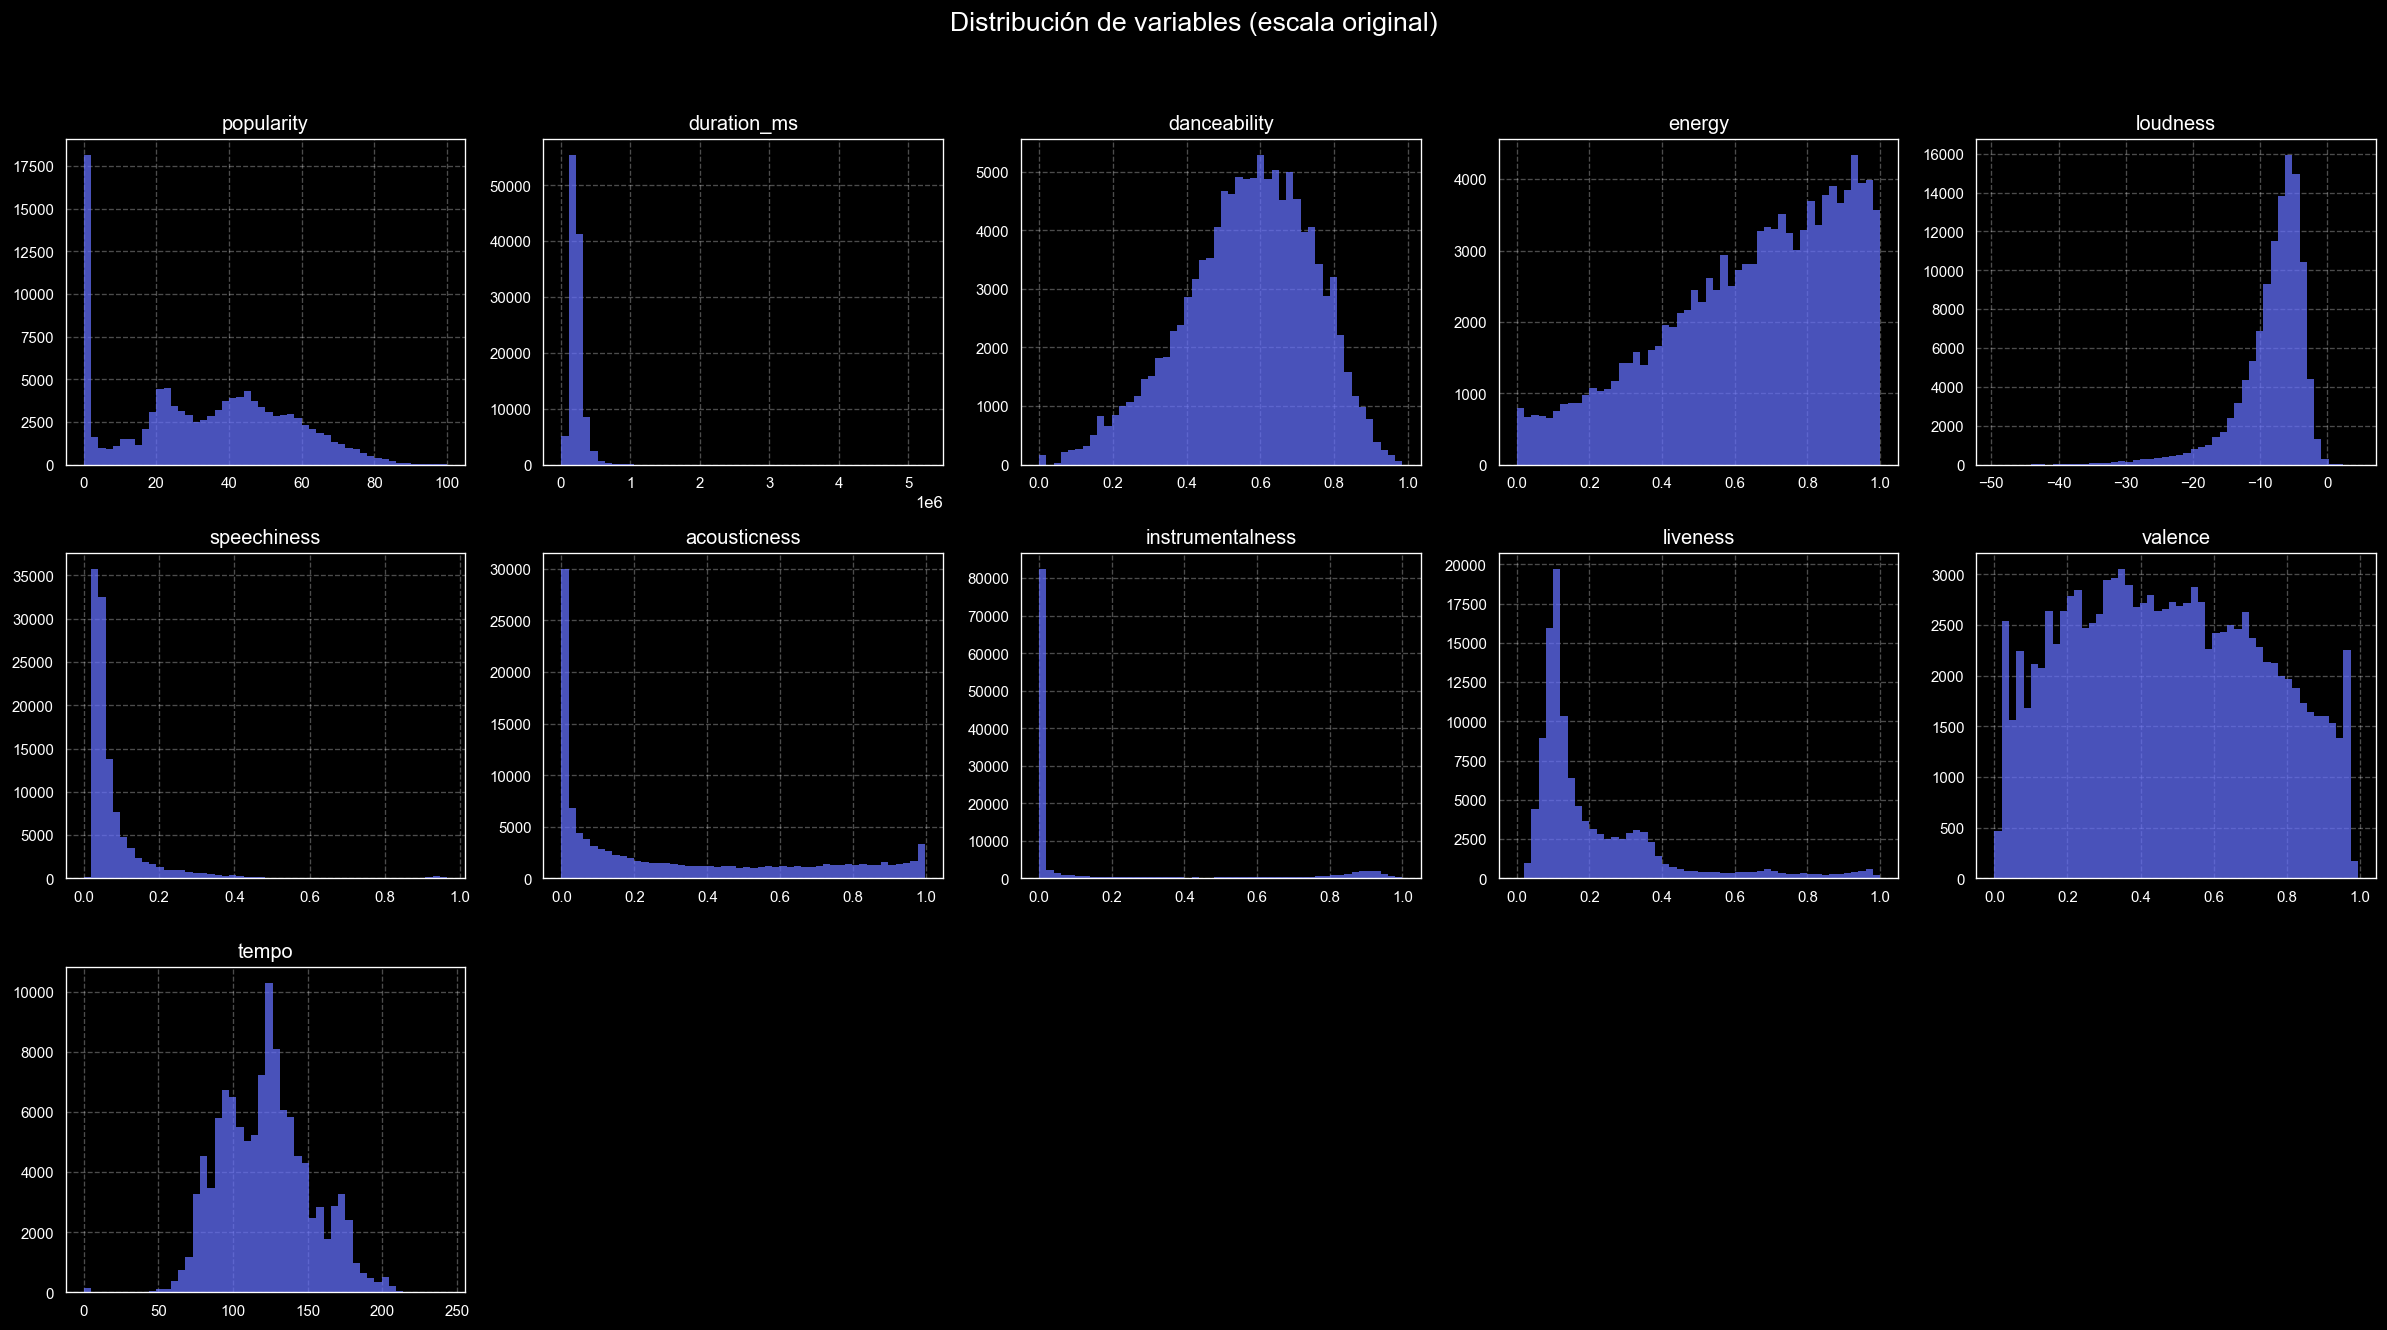

In [35]:
columnas_cuantitativas = ['popularity', 'duration_ms', 'danceability', 'energy', 
    'loudness', 'speechiness', 'acousticness', 'instrumentalness', 
    'liveness', 'valence', 'tempo']

n = len(columnas_cuantitativas)
n_cols = 5
n_rows = math.ceil(n / n_cols)

plt.style.use('dark_background')
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 4 * n_rows))
fig.suptitle("Distribución de variables (escala original)", fontsize=16, y=0.95)

axes_flat = axes.flatten()

for i, col_name in enumerate(columnas_cuantitativas):
    ax = axes_flat[i]
    
    ax.hist(df_raw[col_name], bins=50, color='#636EFA', alpha=0.75, edgecolor='none')
    
    ax.set_title(col_name, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=9)

for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

#### Tests de normalidad, asimetría y colas

In [36]:
resultados = []

for col in columnas_cuantitativas:
    serie = df_raw[col].dropna()
    stat, p = stats.shapiro(serie)
    resultados.append({
        "variable": col,
        "statistic": stat,
        "p_value": round(p,5)})

pd.DataFrame(resultados)

,variable,statistic,p_value
0,popularity,0.957533,0.0
1,duration_ms,0.658652,0.0
2,danceability,0.987069,0.0
3,energy,0.945791,0.0
4,loudness,0.838111,0.0
5,speechiness,0.513743,0.0
6,acousticness,0.836289,0.0
7,instrumentalness,0.546103,0.0
8,liveness,0.736374,0.0
9,valence,0.968987,0.0


In [37]:
asimetria = df_raw[columnas_cuantitativas].skew(numeric_only=True)
display(asimetria.sort_values(ascending=False).to_frame(name="Valor de Asimetría"))

,Valor de Asimetría
duration_ms,11.195826
speechiness,4.647493
liveness,2.105728
instrumentalness,1.734392
acousticness,0.727321
tempo,0.232308
valence,0.115097
popularity,0.046393
danceability,-0.399505
energy,-0.597005


In [38]:
curtosis = df_raw[columnas_cuantitativas].kurtosis(numeric_only=True)
display(curtosis.sort_values(ascending=False).to_frame(name="Valor de Curtosis"))

,Valor de Curtosis
duration_ms,354.976627
speechiness,28.824089
loudness,5.896226
liveness,4.378216
instrumentalness,1.270697
tempo,-0.108587
danceability,-0.184515
energy,-0.525725
popularity,-0.927738
acousticness,-0.949889


### ***Variables categóricas***

#### Proporción de clases 

In [39]:
columnas_categoricas = ['explicit', 'mode', 'key', 'time_signature']

summary_list = []

for col in columnas_categoricas:
    counts = df_raw[col].value_counts(normalize=True) * 100
    top_cat = counts.idxmax()
    top_prop = counts.max()
    
    dist_str = " | ".join([f"{k}={v:.2f}%" for k, v in counts.items()])
    summary_list.append({
        "Variable": col,
        "Cat. Dominante": top_cat,
        "Dominancia (%)": round(top_prop, 2),
        "Cardinalidad": df_raw[col].nunique(),
        "Distribución Completa": dist_str})

df_summary = pd.DataFrame(summary_list)
df_summary = df_summary.sort_values(by="Dominancia (%)", ascending=False)

estilos_titulos = [dict(selector="th", props=[("text-align", "center")])]
display(df_summary.style.set_properties(**{'text-align': 'center'}) .set_table_styles(estilos_titulos))

,Variable,Cat. Dominante,Dominancia (%),Cardinalidad,Distribución Completa
0,explicit,False,91.450000,2,False=91.45% | True=8.55%
3,time_signature,4,89.340000,5,4=89.34% | 3=8.07% | 5=1.60% | 1=0.85% | 0=0.14%
1,mode,1,63.760000,2,1=63.76% | 0=36.24%
2,key,7,11.620000,12,7=11.62% | 0=11.46% | 2=10.21% | 9=9.92% | 1=9.45% | 5=8.22% | 11=8.14% | 4=7.90% | 6=6.95% | 10=6.54% | 8=6.46% | 3=3.13%


## **EDA MULTIVARIANTE**

### ***Variables cuantitativas***

#### Matriz de correlaciones

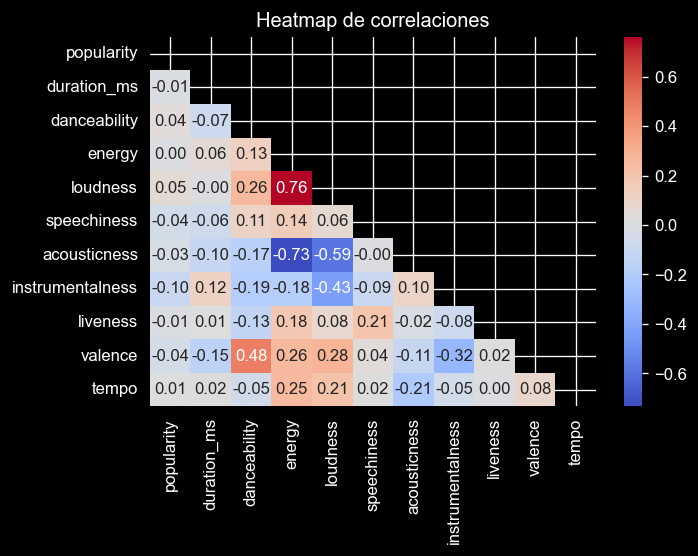

In [40]:
df_cont = df[columnas_cuantitativas]
corr_matrix = df_cont.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(6,4))

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            mask=mask)

plt.title("Heatmap de correlaciones")
plt.show()


#### Factor Inflación Varianza

In [41]:
X_con_constante = add_constant(df_cont)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_con_constante.columns
vif_data["VIF"] = [variance_inflation_factor(X_con_constante.values, i) for i in range(X_con_constante.shape[1])]

print(vif_data[vif_data["Variable"] != "const"].sort_values("VIF", ascending=False))

            Variable       VIF
4             energy  4.251151
5           loudness  3.283747
7       acousticness  2.411396
10           valence  1.582043
3       danceability  1.500687
8   instrumentalness  1.472750
9           liveness  1.141993
6        speechiness  1.129844
11             tempo  1.090256
2        duration_ms  1.054003
1         popularity  1.023106


#### ANOVA

In [42]:
N = len(df_raw)
unique_genres = df_meta["track_genre"].unique()
k = len(unique_genres)

df_between = k - 1
df_within = N - k

resultados_anova = []

for col in columnas_cuantitativas:
    groups = [df_raw.loc[df_meta["track_genre"] == g, col] for g in unique_genres]
    f_stat, p_val = f_oneway(*groups)
    eta_sq = (f_stat * df_between) / ((f_stat * df_between) + df_within)

    resultados_anova.append({"variable": col,
        "f_statistic": f_stat,
        "p_value": p_val,
        "eta_squared": eta_sq })

df_anova = pd.DataFrame(resultados_anova).sort_values(by="eta_squared", ascending=False)

def style_eta_custom(v):
    if v > 0.40:
        return 'background-color: #2E8B57; color: white; font-weight: bold'
    elif v > 0.16:
        return 'background-color: #90EE90; color: black'
    else:
        return 'background-color: #FFFFE0; color: black'

print("="*60)
print("RANKING DE VARIANZA EXPLICADA POR EL GÉNERO (ETA SQUARED)")
print("="*60)

display(df_anova.style.format({
    "f_statistic": "{:.2f}",
    "p_value": "{:.2e}",
    "eta_squared": "{:.4f}"}).applymap(style_eta_custom, subset=['eta_squared']))

RANKING DE VARIANZA EXPLICADA POR EL GÉNERO (ETA SQUARED)


,variable,f_statistic,p_value,eta_squared
6,acousticness,960.16,0.00e+00,0.4879
3,energy,842.84,0.00e+00,0.4554
7,instrumentalness,832.80,0.00e+00,0.4525
4,loudness,828.21,0.00e+00,0.4511
5,speechiness,797.29,0.00e+00,0.4417
2,danceability,714.12,0.00e+00,0.4147
9,valence,441.16,0.00e+00,0.3045
0,popularity,343.54,0.00e+00,0.2542
1,duration_ms,198.56,0.00e+00,0.1646
8,liveness,180.18,0.00e+00,0.1517


### ***Variables categóricas***

#### Chi-cuadrado y V de Cramér

In [43]:
target_series = df_meta['track_genre']

# Función V de Cramér 
def cramers_v_corrected(confusion_matrix):
    """Calcula la V de Cramér con corrección de bias."""

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Corrección de bias 
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    
    denom = min((k_corr-1), (r_corr-1))
    if denom == 0: return 0.0
    return np.sqrt(phi2_corr / denom)


resultados_cat = []
for col in columnas_categoricas:
    tabla = pd.crosstab(df_raw[col], target_series)
    chi2, p, dof, expected = chi2_contingency(tabla)
    
    v_cramer = cramers_v_corrected(tabla)
    
    resultados_cat.append({"Variable": col,
        "Chi2": chi2,         
        "P-Value": p,          
        "V de Cramér": v_cramer })

df_asociacion = pd.DataFrame(resultados_cat).sort_values(by="V de Cramér", ascending=False)

print("="*50)
print("ASOCIACIÓN ENTRE VARIABLES CATEGÓRICAS Y GÉNERO")
print("="*50)

display(df_asociacion.style.background_gradient(cmap="Greens", subset=["V de Cramér"])
        .format({
            "Chi2": "{:.2f}",
            "P-Value": "{:.2e}",
            "V de Cramér": "{:.4f}"}))

ASOCIACIÓN ENTRE VARIABLES CATEGÓRICAS Y GÉNERO


,Variable,Chi2,P-Value,V de Cramér
0,explicit,18460.02,0.00e+00,0.4012
1,mode,7230.10,0.00e+00,0.2499
3,time_signature,26963.99,0.00e+00,0.2411
2,key,9202.17,0.00e+00,0.0797


## Patrones iniciales detectados post-EDA



### Contexto
*   Análisis realizado sobre `df_raw` (sin identificadores).
*   Metadatos (`track_name`, `album_name`, `artists`) segregados.
*   Variable `track_genre` usada como **target ficticio** para evaluar señal discriminante (notando el sesgo potencial en un contexto no supervisado).

---

### 1. Análisis univariante cuantitativo

**Hallazgos clave:**
*   **No normalidad general:** Confirmada mediante histogramas, test de Shapiro-Wilk, skewness y curtosis.
*   **Variables con mayor desviación:** `duration_ms`, `speechiness` e `instrumentalness` (Shapiro stat ≈ 0.5-0.6).
*   **Distorsiones en distribución:**
    *   `duration_ms`: **Sesgo extremo** (Asimetría: 11.2) y **curtosis masiva** (354.9) por *outliers* positivos.
    *   `speechiness`: **Sesgo positivo** marcado (Asimetría: 4.6, Curtosis: 28.8).
    *   `loudness`: Única con **sesgo negativo** (-2.0), indicando saturación en valores altos de volumen.

---

### 2. Análisis univariante categórico

**Transformaciones:**
*   `explicit` (Binaria): Se mantiene. Desbalance (91.4% False / 8.6% True) pero clase minoritaria con valor semántico alto.
*   `time_signature`: Se transforma a binaria `is_time_signature_4` debido a dominancia masiva del compás 4/4 (89.3%). Otras clases (3, 5, 1, 0) agrupadas como "complejidad rítmica".
*   `key` (Nominal): Se mantiene con **One-Hot Encoding completo (12 cols)**. Distribución casi uniforme (clase máxima 11.6%) aporta riqueza armónica.
*   `mode` (Binaria): Se mantiene intacta por balance saludable (64% vs 36%).

---

### 3. Análisis multivariante cuantitativas y categóricas + señal discriminante

**Redundancia (multicolinealidad):**
*   **Relación moderada:** `energy` y `loudness` (Corr: 0.76, VIFs: 4.25 y 3.28). A vigilar en PCA.
*   Correlación menor entre `valence` y `danceability`.

**Capacidad separadora por género:**
*   **Alto poder discriminante (η²):** `acousticness` (0.49), `energy` (0.45), `instrumentalness` (0.45).
*   **Bajo poder discriminante:** `tempo` (0.08) y `liveness` (0.15), sugiriendo ser características transversales.
*   **Asociación categórica (V de Cramér):** Débil-moderada. `key` muestra asociación baja, `mode` y la nueva `time_signature` aportan estructura pero no son determinantes.

---

### Conclusión para Modelado

* **Potencial:** Alta separabilidad por variables fuertes (`acousticness`, `energy`).
* **Requisito Crítico:** Tratamiento robusto de *outliers* (`duration_ms`) y transformaciones para no-normalidad.
* **Conservación total de características**: Se descarta el filtro/combinación manual de características al no haber problemas evidentes que no sean solucionables por las herramientas de reducción de dimensionalidad y clustering.

## **PIPELINE PREPROCESADO**

### Feature engineering básico y outlier clipping

In [44]:
def ingenieria_basica(df):
    """
    Transforma explicit a int y crea la variable rítmica binaria.
    """
    X = df.copy()
    if 'explicit' in X.columns:
        X['explicit'] = X['explicit'].astype(int)
    
    if 'time_signature' in X.columns:
        # 1 si es 4/4, 0 si es complejo (3, 5, 1, 0)
        X['is_time_signature_4'] = np.where(X['time_signature'] == 4, 1, 0)
        X = X.drop(columns=['time_signature'])
        
    if 'mode' in X.columns:
        X['mode'] = X['mode'].astype(int)
        
    return X

In [45]:
def clipear_outliers_especificos(df):
    """
    Recorta outliers solo en duration_ms y speechiness al percentil 99 
    para mayor estabilidad
    """
    X = df.copy()
    cols_to_clip = ['duration_ms', 'speechiness']

    for col in cols_to_clip:
        if col in X.columns:
            limite = X[col].quantile(0.99)
            X[col] = X[col].clip(upper=limite)         
    return X

### Construcción de pipelines e integración

In [46]:
# Columnas sin modificaciones
columnas_directas = ['explicit', 'mode', 'is_time_signature_4']

# --- SUB-PIPELINE NUMÉRICO ---
# Recorte de outliers + normalización estadística (Yeo-Johnson).
pipe_numerico = Pipeline([
    ('clipping', FunctionTransformer(clipear_outliers_especificos, validate=False)),
    ('yeo_johnson', PowerTransformer(method='yeo-johnson', standardize=True))]) #aplicado a todo el df sin caer en data leakage

# --- DISTRIBUIDOR CENTRAL ---
# Procesos en paralelo:
# - Numéricas -> Clipping + Scaling
# - Key -> One-Hot Encoding
# - Binarias -> Passthrough (Paso directo)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', pipe_numerico, columnas_cuantitativas),
        ('cat_key', OneHotEncoder(sparse_output=False, dtype=int, handle_unknown='ignore'), ['key']),
        ('pass', 'passthrough', columnas_directas)],verbose_feature_names_out=False).set_output(transform="pandas")


# --- PIPELINE FINAL ---
# Integra la ingeniería de características inicial con las transformaciones por columna.
pipeline_global = Pipeline([
    ('ingenieria', FunctionTransformer(ingenieria_basica, validate=False)),
    ('transformacion', preprocessor)])

### Aplicación y validación

In [47]:
df_scaled = pipeline_global.fit_transform(df_raw)

print("Pipeline completado.")
print(f"Dimensiones df_raw:   {df_raw.shape}")
print(f"Dimensiones df_scaled: {df_scaled.shape}")
print("\nPrimeras filas del resultado:")
display(df_scaled.head())

Pipeline completado.
Dimensiones df_raw:   (113999, 15)
Dimensiones df_scaled: (113999, 26)

Primeras filas del resultado:


,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,...,key_5,key_6,key_7,key_8,key_9,key_10,key_11,explicit,mode,is_time_signature_4
0,1.505743,0.180885,0.599380,-0.827804,0.132593,1.486978,-0.933744,-0.593842,1.261167,0.935621,...,0,0,0,0,0,0,0,0,0,1
1,0.934271,-0.955125,-0.886325,-1.675387,-1.658038,0.528638,1.492172,-0.593753,-0.701486,-0.779562,...,0,0,0,0,0,0,0,0,1,1
2,1.000641,-0.068699,-0.792279,-1.158407,-0.538749,-0.044725,-0.018783,-0.593862,-0.475311,-1.414828,...,0,0,0,0,0,0,0,0,1,1
3,1.444853,-0.185688,-1.628365,-1.904202,-1.803951,-0.797526,1.471943,-0.592475,-0.282743,-1.312492,...,0,0,0,0,0,0,0,0,1,0
4,1.772967,-0.227008,0.234509,-0.889175,-0.528464,-0.149209,0.778256,-0.593862,-0.986411,-1.206921,...,0,0,0,0,0,0,0,0,1,1


## **DIMENSIONALIDAD - FEATURE EXTRACTION**

### ***PCA***

#### Ejecución

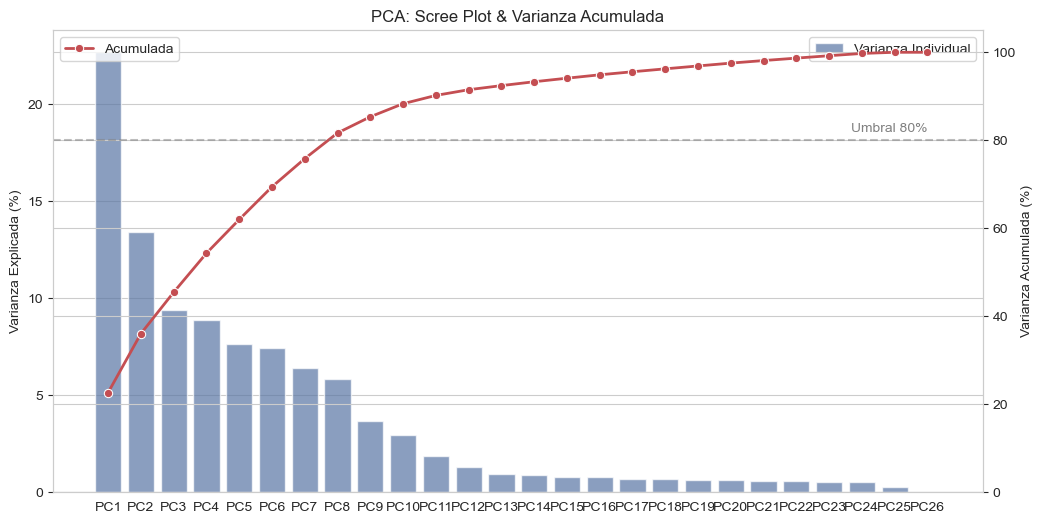

,PC,Eigenvalue,Var_Explicada (%),Var_Acumulada (%)
0,PC1,2.792175,22.673087,22.673087
1,PC2,1.649722,13.396115,36.069202
2,PC3,1.157045,9.395465,45.464667
3,PC4,1.092909,8.874666,54.339333
4,PC5,0.942786,7.655634,61.994967
5,PC6,0.915817,7.436638,69.431605
6,PC7,0.788345,6.401541,75.833145
7,PC8,0.717697,5.827862,81.661007
8,PC9,0.453060,3.678950,85.339957
9,PC10,0.366131,2.973062,88.313019


In [48]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# 1. Ajustar PCA
pca = PCA()
pca.fit(df_scaled)

# 2. Obtener métricas
explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)
n_components = len(explained_variance)
eigenvalues = pca.explained_variance_ 

# 3. Scree Plot 
plt.figure(figsize=(12, 6))
x_labels = [f'PC{i+1}' for i in range(n_components)]
ax1 = sns.barplot(x=x_labels, y=explained_variance, color='#4c72b0', alpha=0.7, label='Varianza Individual')
ax2 = plt.twinx()
sns.lineplot(x=x_labels, y=cumulative_variance, color='#c44e52', marker='o', linewidth=2, ax=ax2, label='Acumulada')

ax1.set_ylabel('Varianza Explicada (%)')
ax2.set_ylabel('Varianza Acumulada (%)')
ax2.set_ylim(0, 105)
ax2.axhline(y=80, color='grey', linestyle='--', alpha=0.5) 
ax2.text(n_components-1, 82, 'Umbral 80%', color='grey', ha='right')

plt.title('PCA: Scree Plot & Varianza Acumulada')
plt.show()

df_variance = pd.DataFrame({
    'PC': x_labels,
    'Eigenvalue': eigenvalues,
    'Var_Explicada (%)': explained_variance,
    'Var_Acumulada (%)': cumulative_variance})
display(df_variance.head(10))

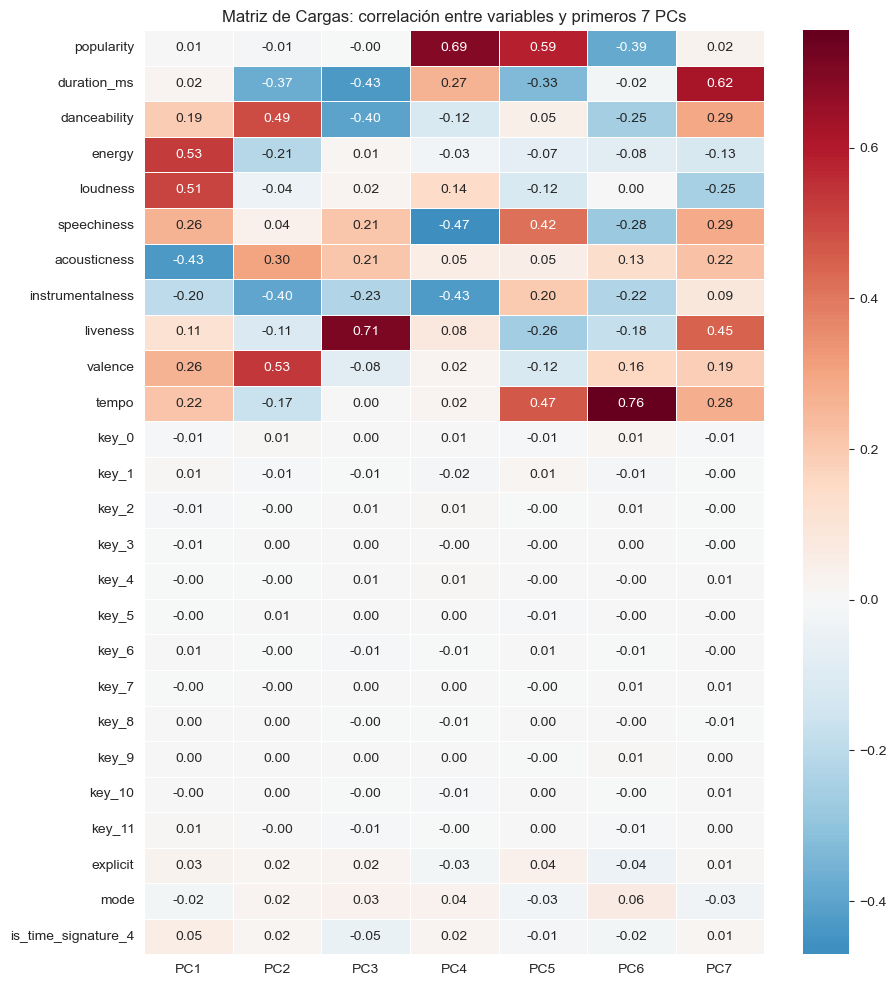

In [49]:
num_pcs_analisis = 7
cols_pc = [f'PC{i+1}' for i in range(num_pcs_analisis)]

loadings_df = pd.DataFrame(pca.components_[:num_pcs_analisis].T, 
    columns=cols_pc, 
    index=df_scaled.columns)

plt.figure(figsize=(10, 12))
sns.heatmap(loadings_df, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title(f'Matriz de Cargas: correlación entre variables y primeros {num_pcs_analisis} PCs')
plt.show()

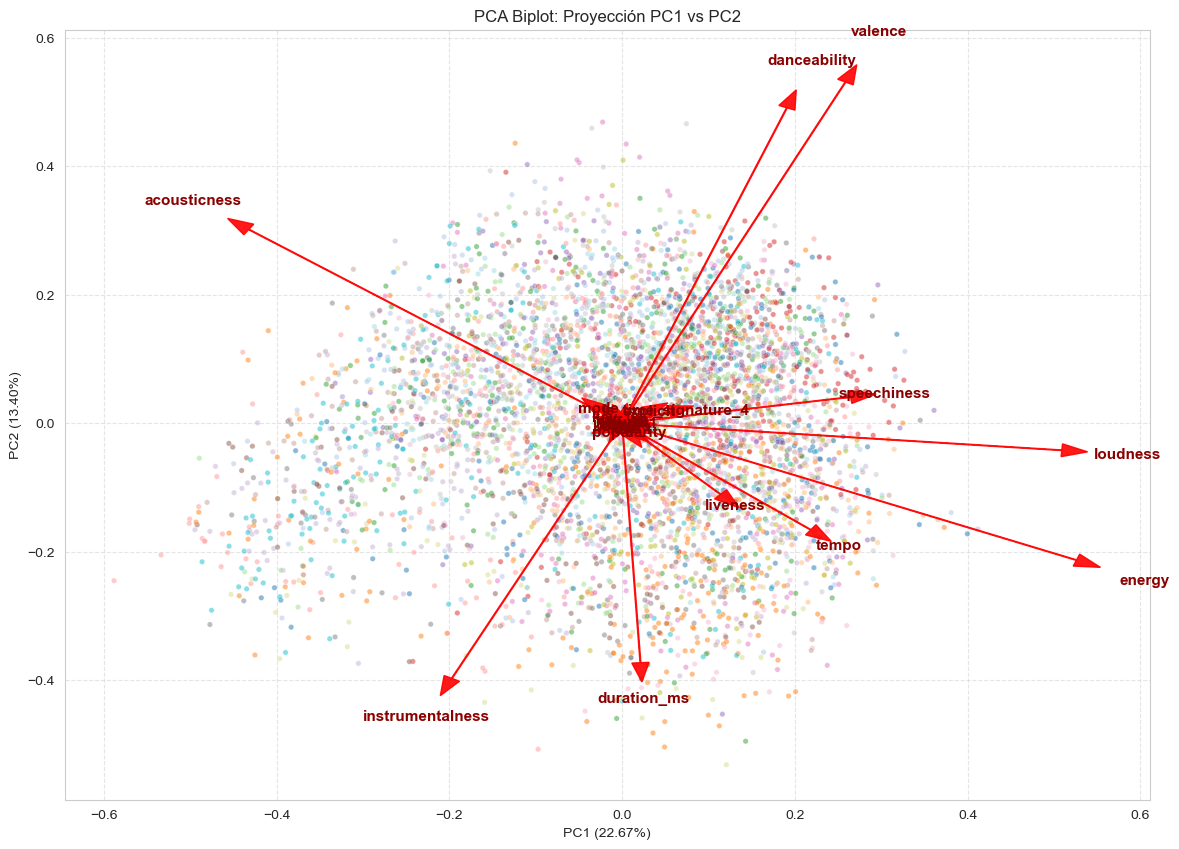

In [50]:
# 1.Proyección
pca_data = pca.transform(df_scaled)
df_pca = pd.DataFrame(pca_data, columns=[f'PC{i+1}' for i in range(n_components)])

# Añadimos el género para colorear
df_pca['genre'] = df_meta['track_genre'].values

# 2. Biplot (Scatter + Vectores)
def plot_biplot(score, coeff, labels=None, color_col=None):
    plt.figure(figsize=(14, 10))
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    sns.scatterplot(x=xs * scalex, y=ys * scaley, hue=color_col, alpha=0.5, s=15, palette='tab20', legend=False)

    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], color='red', alpha=0.9, head_width=0.02)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color='black', ha='center', va='center', weight='bold')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color='darkred', ha='center', va='center', weight='bold', fontsize=11)
            
    plt.xlabel(f"PC1 ({explained_variance[0]:.2f}%)")
    plt.ylabel(f"PC2 ({explained_variance[1]:.2f}%)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.title("PCA Biplot: Proyección PC1 vs PC2")

# Muestra aleatoria de 5000 puntos
indices_muestra = np.random.choice(df_pca.shape[0], 5000, replace=False)
plot_biplot(df_pca.iloc[indices_muestra, :2].values, 
    pca.components_[:2].T, 
    labels=df_scaled.columns,
    color_col=df_pca.iloc[indices_muestra]['genre'])
plt.show()

#### Patrones e interpretaciones sobre el PCA

##### Heatmap de cargas
*   **Variables débiles:** Las filas correspondientes a `key_0` a `key_11`, `mode`, `explicit` y `is_time_signature_4` (categóricas) aparecen casi completamente en blanco en la imagen de cargas.
*   **Interpretación:** Los valores cercanos a **0.00** confirman que estas variables **no aportan varianza significativa** a la estructura global de los datos.
*   **Conclusión:** Estas variables están diluyendo la señal útil en lugar de reforzarla, validando la hipótesis previa sobre su bajo poder discriminante.

---

##### Interpretación del Scree Plot
*   **Compresión Ineficiente:** Se requieren aproximadamente **9 componentes principales** para capturar el **80% de la varianza** acumulada.
*   **Implicación:** Este descenso lento del *scree plot* indica que la **complejidad intrínseca** de los datos es alta.
*   **Conclusión para el modelo:** El PCA lineal **no logra comprimir la información de manera eficiente**, lo que sugiere que las relaciones subyacentes en los datos pueden ser no lineales.


## ***T-SNE***

### Ejecución

In [51]:
sns.set_style("darkgrid")
plt.rcParams['figure.dpi'] = 120

# 1. PREPARACIÓN DE DATOS (Usando PCA como pre-filtro)
# Seleccionamos los componentes que acumulan aprox el 80-85% de varianza
n_components_pca = 12 
pca_cols = [f'PC{i+1}' for i in range(n_components_pca)]
X_input_tsne = df_pca[pca_cols].values


#Muestra de 30k = representativa para visualización.
SAMPLE_SIZE = 30000 
if len(X_input_tsne) > SAMPLE_SIZE:
    indices = np.random.choice(len(X_input_tsne), SAMPLE_SIZE, replace=False)
    X_subset = X_input_tsne[indices]
    genres_subset = df_meta['track_genre'].iloc[indices].values
else:
    X_subset = X_input_tsne
    genres_subset = df_meta['track_genre'].values


In [52]:
tsne = TSNE(n_components=2,perplexity=40,learning_rate='auto',
    n_iter=1000,init='pca',random_state=42,n_jobs=-1,verbose=1)

tsne_results = tsne.fit_transform(X_subset)
print(f"Kullback-Leibler divergence: {tsne.kl_divergence_:.4f}")

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.057s...
[t-SNE] Computed neighbors for 30000 samples in 5.518s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sa

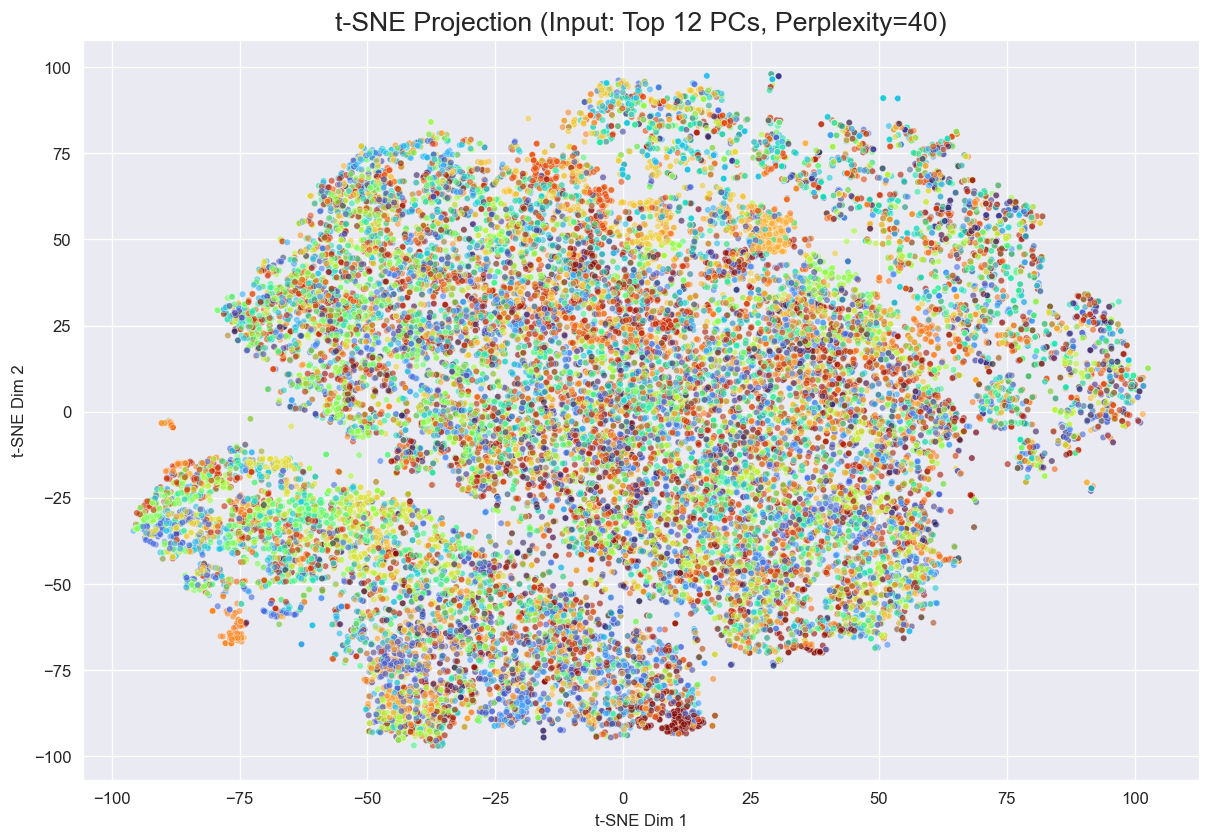

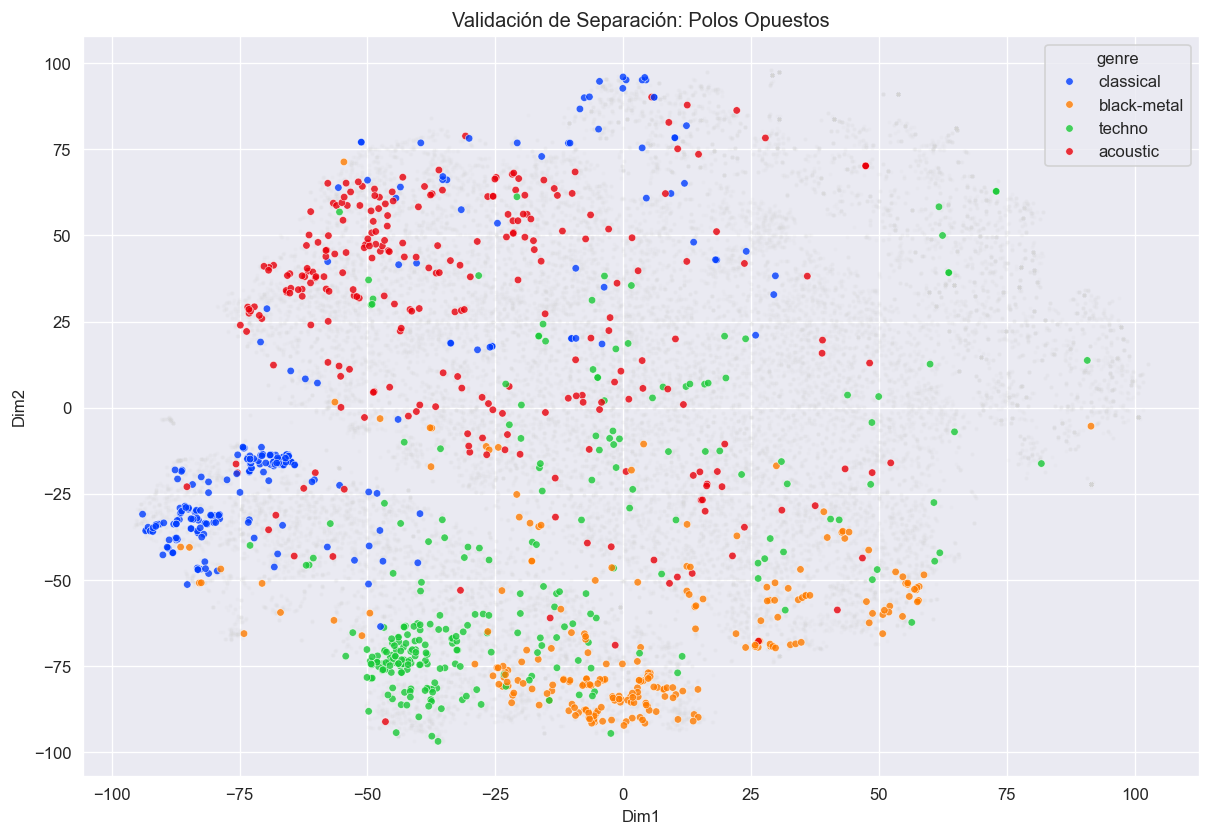

In [53]:
df_tsne = pd.DataFrame(tsne_results, columns=['Dim1', 'Dim2'])
df_tsne['genre'] = genres_subset

plt.figure(figsize=(12,8))

sns.scatterplot(x="Dim1", y="Dim2",
    hue="genre",
    palette="turbo",
    data=df_tsne,
    legend=False,    # Desactivamos leyenda por legibilidad
    alpha=0.6,
    s=15)

plt.title(f't-SNE Projection (Input: Top {n_components_pca} PCs, Perplexity=40)', fontsize=16)
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.show()

def plot_genre_highlight(target_genres, title):
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x="Dim1", y="Dim2", data=df_tsne, color='lightgrey', alpha=0.1, s=5)
    subset = df_tsne[df_tsne['genre'].isin(target_genres)]
    sns.scatterplot(x="Dim1", y="Dim2", hue="genre", data=subset, palette='bright', s=20, alpha=0.8)
    plt.title(title)
    plt.show()

plot_genre_highlight(['classical', 'black-metal', 'techno', 'acoustic'], "Validación de Separación: Polos Opuestos")

### Patrones e interpretaciones sobre el t-SNE

##### Espacio continuo de puntos
*   **Observación:** La proyección general muestra una **masa única y continua** de puntos.
*   **Interpretación:** Este patrón demuestra la **ausencia de fronteras rígidas** entre géneros. Se observan transiciones fluidas: "Pop" → "Dance" → "Techno", "Rock" → "Metal".
*   **Causalidad:** Al trabajar con **114 géneros**, los datos han llenado casi todos los **espacios vacíos** posibles entre los estilos extremos. 

---

##### Validación del Algoritmo (Éxito Local)
*   **Evidencia:** El gráfico de validación **demuestra que el agrupamiento sí funciona**.
*   **Patrones de Agrupación Correcta:**
    *   **Techno (azul):** Concentrado abajo a la izquierda.
    *   **Black Metal (naranja):** Agrupado abajo al centro/derecha.
    *   **Clásica (verde):** Ubicada arriba a la izquierda.
*   **Conclusión Final:** El algoritmo **agrupa correctamente** las muestras por similitud sonora intrínseca. La percepción de una sola "nube" surge al superponer los otros **110 géneros (en gris)**, que llenan completamente el espacio intermedio.

## ***UMAP***

### Ejecución

In [54]:
sns.set_style("darkgrid")
print(f"Iniciando UMAP con {len(X_subset)} muestras...")

reducer = umap.UMAP(n_neighbors=50, 
    min_dist=0.3, 
    n_components=2, 
    metric='euclidean', 
    random_state=42,
    verbose=True)

embedding = reducer.fit_transform(X_subset)

Iniciando UMAP con 30000 muestras...
UMAP(min_dist=0.3, n_jobs=1, n_neighbors=50, random_state=42, verbose=True)
Fri Dec 19 20:27:51 2025 Construct fuzzy simplicial set
Fri Dec 19 20:27:51 2025 Finding Nearest Neighbors
Fri Dec 19 20:27:51 2025 Building RP forest with 14 trees
Fri Dec 19 20:27:59 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	Stopping threshold met -- exiting after 3 iterations
Fri Dec 19 20:28:16 2025 Finished Nearest Neighbor Search
Fri Dec 19 20:28:19 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Fri Dec 19 20:28:46 2025 Finished embedding


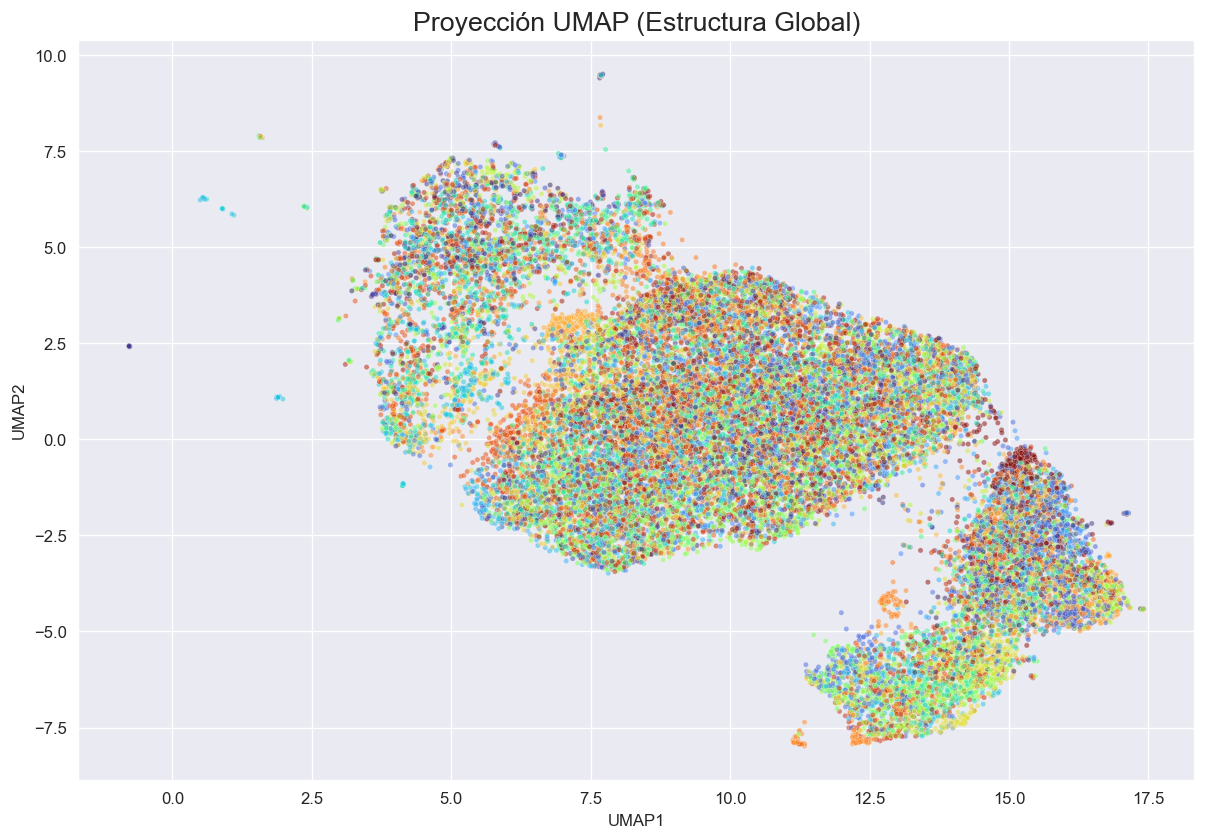

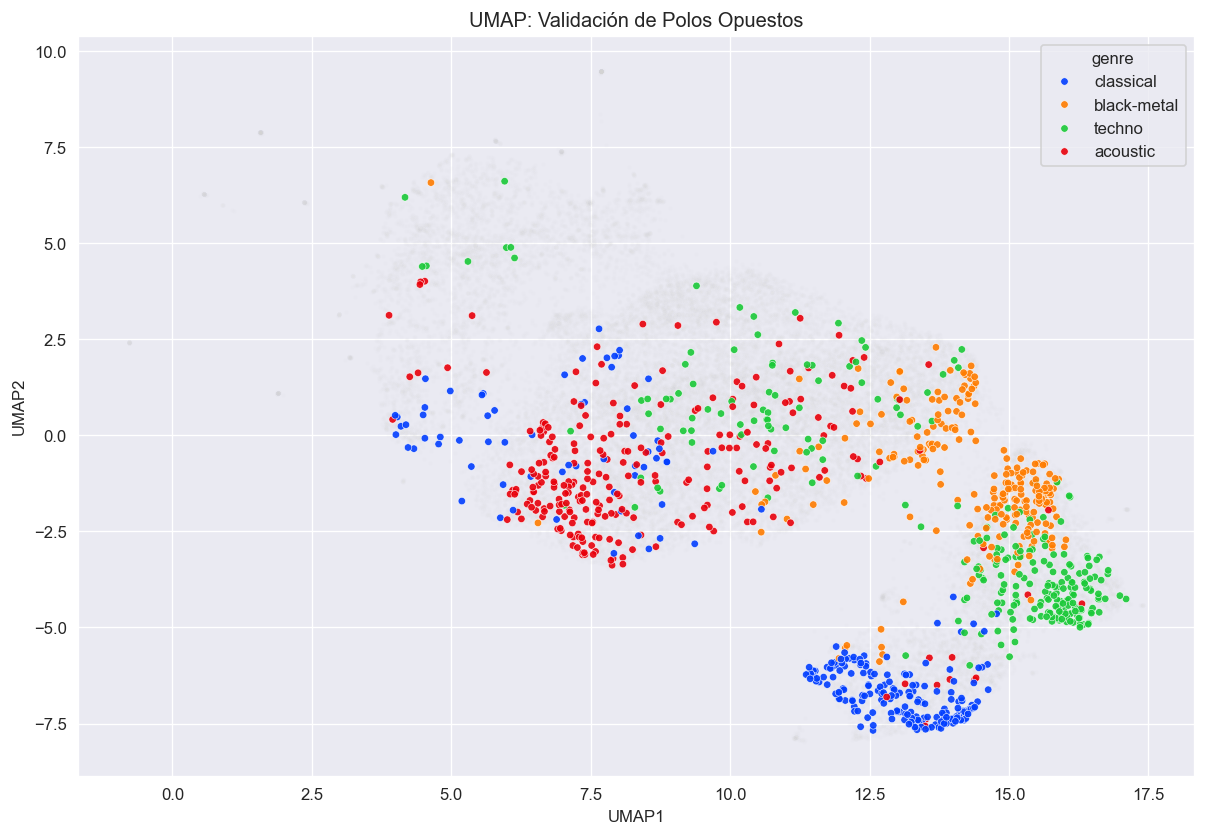

In [55]:
df_umap = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
df_umap['genre'] = genres_subset

plt.figure(figsize=(12, 8))
sns.scatterplot(x="UMAP1", y="UMAP2",
    hue="genre",
    palette="turbo",
    data=df_umap,
    legend=False,
    alpha=0.5,
    s=10)
plt.title('Proyección UMAP (Estructura Global)', fontsize=16)
plt.show()

def plot_genre_highlight_umap(target_genres, title):
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x="UMAP1", y="UMAP2", data=df_umap, color='lightgrey', alpha=0.05, s=5)
    
    subset = df_umap[df_umap['genre'].isin(target_genres)]
    sns.scatterplot(x="UMAP1", y="UMAP2", hue="genre", data=subset, palette='bright', s=20, alpha=0.9)
    plt.title(title)
    plt.show()

plot_genre_highlight_umap(['classical', 'black-metal', 'techno', 'acoustic'], "UMAP: Validación de Polos Opuestos")

### Patrones e interpretaciones sobre el UMAP

#### Complejidad comprimida
UMAP generó un embedding bidimensional que define **fronteras difusas dentro de un espectro continuo**, no clusters aislados.

#### Hallazgos Técnicos
*   **Reducción Dimensional Exitosa:** Se comprimieron **26 features originales** a **2 componentes UMAP** conservando la estructura de los datos.
*   **Preservación de Relaciones Semánticas:** El embedding mantiene las relaciones de similitud musical.
*   **Confirmación del Continuo Musical:** Los 114 géneros llenan completamente el espacio, formando una **masa de datos continua** sin separaciones naturales.

## Análisis dimensionalidad

### Resumen
El análisis secuencial reveló la topología compleja y no lineal del conjunto de datos musical, evidenciando un **espectro continuo de géneros**.

### 1. PCA
*   **Hallazgo:** Confirmó la **no-linealidad** de la estructura musical. El *scree plot* (sin codo definido) indicó la ausencia de un subconjunto pequeño de variables maestras.
*   **Contribución:** Actuó como **herramienta de limpieza**, identificando y permitiendo descartar variables categóricas (`key`, `mode`, `time_signature` y `explicit`) al mostrar cargas nulas.
*   **Limitación:** Incapaz de generar una separación visual útil en 2D.

### 2. t-SNE
*   **Hallazgo:** Aplicado sobre componentes PCA, **validó la coherencia local** (agrupación correcta de sub-géneros)
*   **Limitación:** Organizó vecinos pero **fallando en preservar la estructura global** (sin distancias interpretables entre clusters lejanos).

### 3. UMAP
*   **Hallazgo:** Logró **desplegar la topología completa**, demostrando que los géneros forman un **espectro continuo**
*   **Logro:** **Preservó la semántica** al comprimir 26 variables en 2 dimensiones latentes (UMAP1, UMAP2) con ejes interpretables (ej. acústico ↔ electrónico/denso) y aislar polos opuestos (Clásica vs. Metal/Techno).

## **CLUSTERING**

### ***Centroid: K-Means***

In [56]:
sns.set_style("whitegrid")
n_components_pca = 12 
pca_cols = [f'PC{i+1}' for i in range(n_components_pca)]
X_clustering = df_pca[pca_cols].values

# Desde K=2 hasta K=12
inertia = []
silhouette_scores = []
k_range = range(2, 13)
sample_size_silhouette = 30000 # Muestreo 

print(f"\nIniciando búsqueda de K óptimo (Muestreo Silueta: {sample_size_silhouette})...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_clustering)
    inertia.append(kmeans.inertia_)
    indices = np.random.choice(len(X_clustering), sample_size_silhouette, replace=False)
    score = silhouette_score(X_clustering[indices], kmeans.labels_[indices])
    silhouette_scores.append(score)



Iniciando búsqueda de K óptimo (Muestreo Silueta: 30000)...


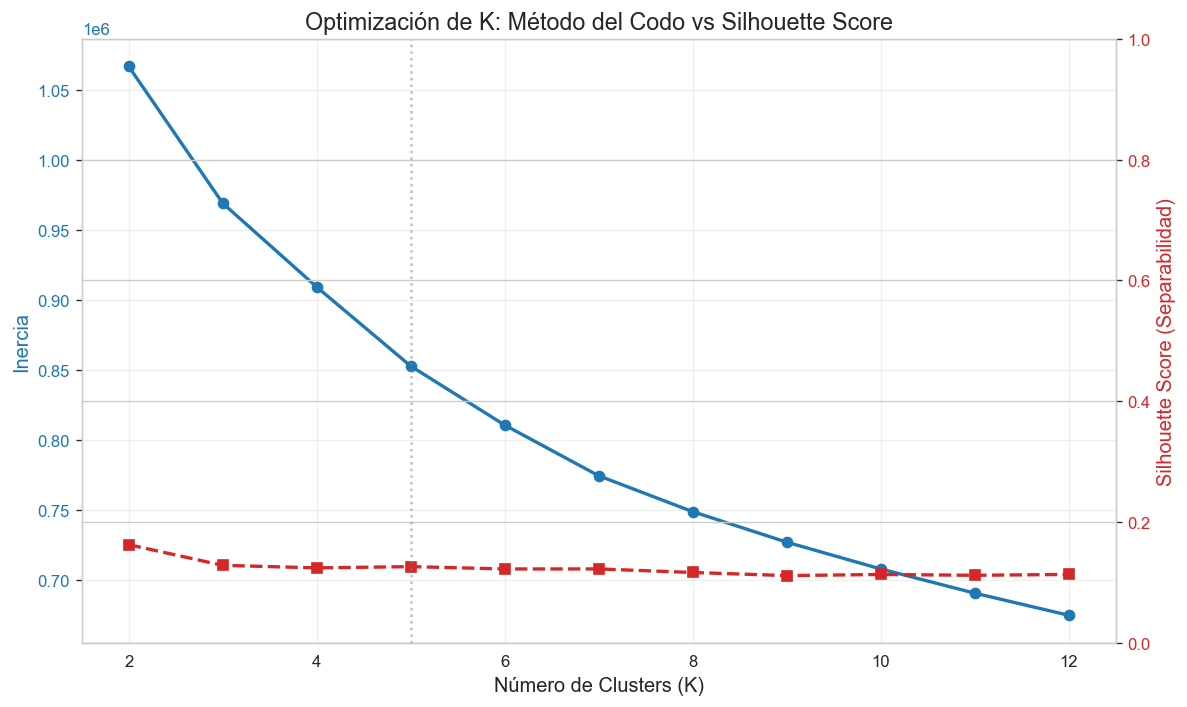

In [57]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje Y1: Inercia (Elbow)
color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (K)', fontsize=12)
ax1.set_ylabel('Inercia', color=color, fontsize=12)
ax1.plot(k_range, inertia, marker='o', linestyle='-', color=color, linewidth=2, label='Inercia (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Eje Y2: Silhouette Score
ax2 = ax1.twinx() 
color = 'tab:red'
ax2.set_ylabel('Silhouette Score (Separabilidad)', color=color, fontsize=12)
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='--', color=color, linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1) 

plt.title('Optimización de K: Método del Codo vs Silhouette Score', fontsize=14)
plt.axvline(x=5, color='grey', linestyle=':', alpha=0.5)
fig.tight_layout()
plt.show()

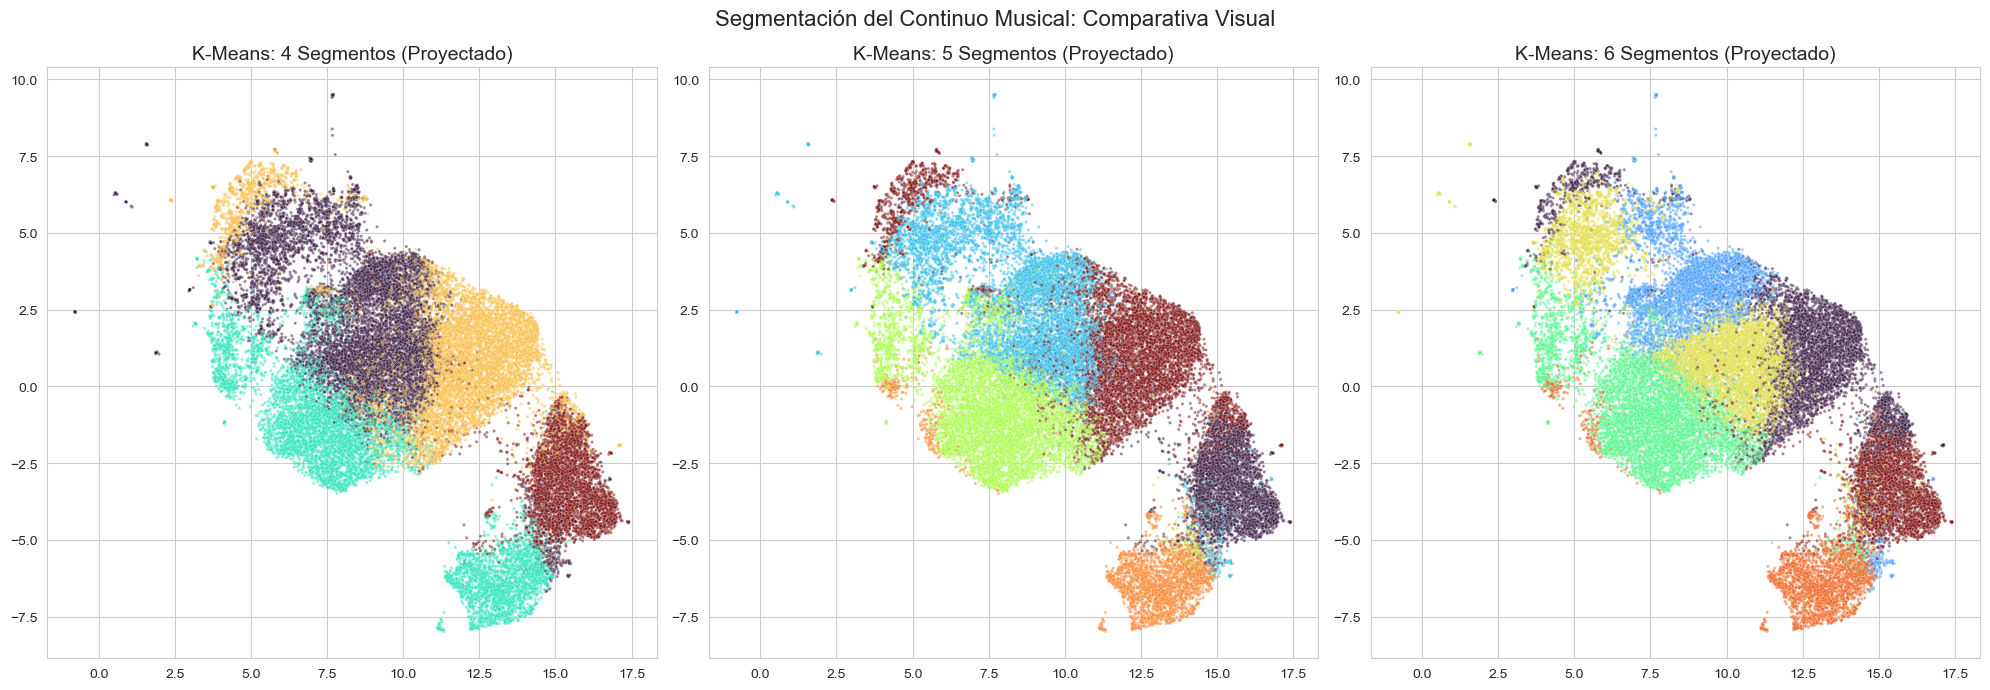

In [58]:
# VISUALIZACIÓN DE CORTES K-MEANS SOBRE UMAP (Corregido)
plt.rcParams['figure.dpi'] = 100

k_candidates = [4, 5, 6]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, k in enumerate(k_candidates):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_clustering) 
    labels_for_plot = kmeans.predict(X_subset)
    sns.scatterplot(
        x=df_umap['UMAP1'], y=df_umap['UMAP2'], 
        hue=labels_for_plot, 
        palette='turbo',
        s=5, alpha=0.5, legend=False, ax=axes[i])
    
    axes[i].set_title(f'K-Means: {k} Segmentos (Proyectado)', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle('Segmentación del Continuo Musical: Comparativa Visual', fontsize=16)
plt.tight_layout()
plt.show()

#### Hallazgos K-means

El análisis con K-Means revela que los datos musicales forman un **espectro continuo**, no una colección de grupos aislados. Una partición rígida basada en distancia euclidiana **no es la estrategia óptima** para este caso.

#### Ausencia de fronteras (Elbow Method)
*   **Observación:** El gráfico de optimización muestra un **descenso suave de la inercia**.
*   **Interpretación:** Confirma que **no existen grupos compactos** separados por vacíos claros. La varianza se distribuye de forma homogénea.

#### Segmentación arbitraria
*   **Observación:** Sobre el mapa UMAP, los clusters aparecen **fragmentados y mezclados** en las zonas de transición.
*   **Interpretación:** K-Means está **forzando cortes artificiales** en zonas densas. Esto agrupa canciones muy distintas solo por cercanía matemática, generando **ruido en la interpretación**.

#### Limitación 
*   **Observación:** K-Means asume que los grupos son **esferas perfectas** (clusters hiperesféricos).
*   **Interpretación:** La topología musical real es **compleja y alargada** (como mostró UMAP). El algoritmo no se adapta a estas formas flexibles, resultando en una **segmentación poco robusta**.

Se descarta **K-Means como modelo final** debido a su incapacidad para gestionar la continuidad y solapamiento de los géneros musicales. Se requiere una transición a **modelos probabilísticos** (GMM), que permiten **fronteras más suaves y adaptables** a la realidad de los datos.

### ***Distribuciones: GMM***

In [59]:
n_components_range = range(2, 13)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(X_clustering)
    bic_scores.append(gmm.bic(X_clustering))
    aic_scores.append(gmm.aic(X_clustering))

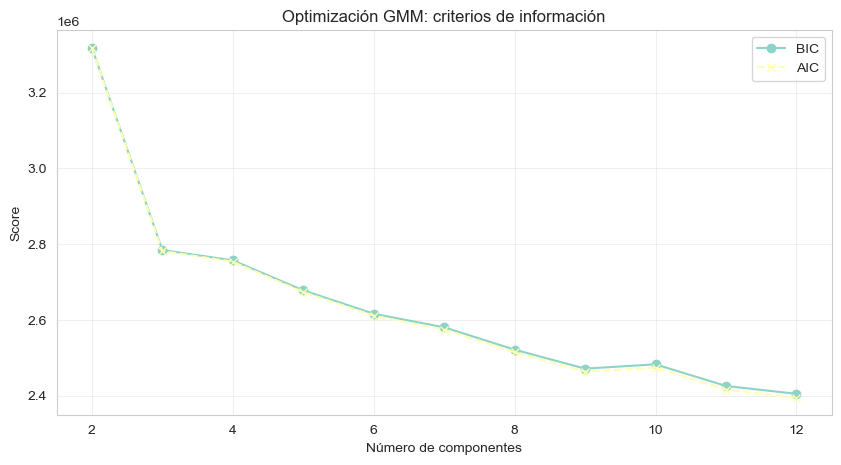

In [60]:
plt.figure(figsize=(10, 5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.plot(n_components_range, aic_scores, label='AIC', marker='x', linestyle='--')
plt.legend()
plt.title('Optimización GMM: criterios de información')
plt.xlabel('Número de componentes')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)
plt.show()

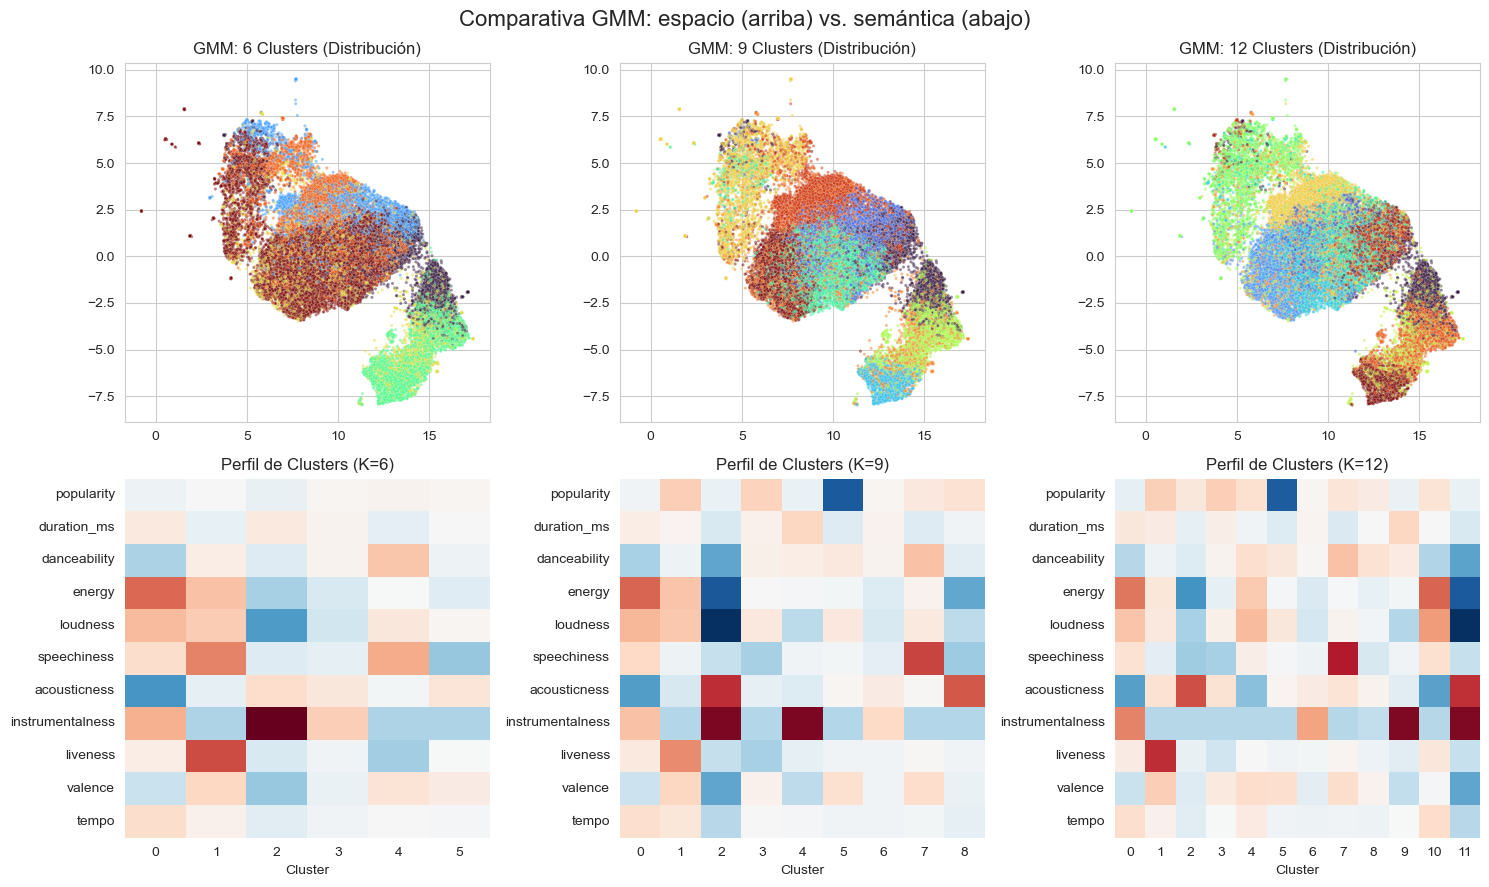

In [61]:
plt.rcParams['figure.dpi'] = 100

candidates = [6, 9, 12]
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 3) 

df_profile = df_scaled.copy()

for i, k in enumerate(candidates):
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    labels_all = gmm.fit_predict(X_clustering) 
    labels_sample = gmm.predict(X_subset)
    ax_map = fig.add_subplot(gs[0, i])

    sns.scatterplot(x=df_umap['UMAP1'], y=df_umap['UMAP2'], 
        hue=labels_sample, 
        palette='turbo', 
        s=5, alpha=0.5, legend=False, ax=ax_map)
    ax_map.set_title(f'GMM: {k} Clusters (Distribución)', fontsize=12)
    ax_map.set_xlabel('')
    ax_map.set_ylabel('')

    df_profile['Cluster'] = labels_all
    cluster_means = df_profile.groupby('Cluster')[columnas_cuantitativas].mean()

    ax_heat = fig.add_subplot(gs[1, i])
    sns.heatmap(cluster_means.T,
        cmap='RdBu_r', center=0, 
        annot=False, 
        cbar=False,
        xticklabels=True, yticklabels=True,
        ax=ax_heat)
    ax_heat.set_title(f'Perfil de Clusters (K={k})', fontsize=12)

plt.suptitle('Comparativa GMM: espacio (arriba) vs. semántica (abajo)', fontsize=16)
plt.tight_layout()
plt.show()

In [63]:
# ENTRENAMIENTO FINAL (K=9)
gmm_final = GaussianMixture(n_components=9, covariance_type='full', random_state=42)
labels_final = gmm_final.fit_predict(X_clustering) 

df_scaled['Cluster_GMM'] = labels_final
df_meta['Cluster_GMM'] = labels_final 

cluster_profile = df_scaled.groupby('Cluster_GMM')[columnas_cuantitativas].mean()
cluster_counts = df_scaled['Cluster_GMM'].value_counts().sort_index()
cluster_profile['Count'] = cluster_counts
cluster_profile['% Total'] = (cluster_counts / len(df_scaled)) * 100

print("\n--- Top Géneros más comunes por Cluster ---")
for i in range(9):
    top_genres = df_meta[df_meta['Cluster_GMM'] == i]['track_genre'].value_counts().head(4).index.tolist()
    print(f"Cluster {i}: {top_genres}")


display(cluster_profile.style
        .format(precision=2)                         
        .background_gradient(cmap='RdBu_r', axis=0)  
        .set_properties(**{'text-align': 'center'}))


--- Top Géneros más comunes por Cluster ---
Cluster 0: ['death-metal', 'grindcore', 'black-metal', 'metalcore']
Cluster 1: ['pagode', 'sertanejo', 'forro', 'samba']
Cluster 2: ['new-age', 'classical', 'ambient', 'piano']
Cluster 3: ['world-music', 'salsa', 'mandopop', 'grunge']
Cluster 4: ['minimal-techno', 'detroit-techno', 'study', 'idm']
Cluster 5: ['jazz', 'soul', 'country', 'latin']
Cluster 6: ['trip-hop', 'romance', 'bluegrass', 'opera']
Cluster 7: ['comedy', 'j-dance', 'dancehall', 'kids']
Cluster 8: ['honky-tonk', 'cantopop', 'mandopop', 'acoustic']


,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Count,% Total
Cluster_GMM,,,,,,,,,,,,,
0,-0.10,0.16,-0.65,1.19,0.69,0.41,-1.14,0.61,0.19,-0.43,0.35,11798,10.35
1,0.50,0.05,-0.11,0.58,0.55,-0.11,-0.34,-0.59,0.97,0.44,0.24,16202,14.21
2,-0.14,-0.33,-1.08,-1.74,-2.06,-0.47,1.51,1.94,-0.48,-1.07,-0.56,4850,4.25
3,0.46,0.11,0.13,0.01,0.21,-0.67,-0.19,-0.59,-0.67,0.10,0.02,16372,14.36
4,-0.15,0.43,0.15,-0.03,-0.55,-0.10,-0.28,1.94,-0.20,-0.54,-0.03,9997,8.77
5,-1.73,-0.27,0.21,-0.05,0.22,-0.04,0.05,-0.59,-0.09,0.33,-0.08,11668,10.24
6,0.04,0.10,0.08,-0.28,-0.34,-0.20,0.16,0.40,-0.08,-0.10,-0.08,15706,13.78
7,0.22,-0.27,0.60,0.09,0.21,1.39,0.03,-0.59,0.03,0.37,-0.05,16607,14.57
8,0.32,-0.10,-0.24,-1.07,-0.53,-0.75,1.27,-0.59,-0.09,-0.15,-0.20,10799,9.47


#### Hallazgos GMM

Tras las limitaciones de K-Means, **Gaussian Mixture Models (GMM)** se establece como la estrategia superior. Su enfoque probabilístico (*Soft Clustering*) se adapta exitosamente a la topología continua y superpuesta de los géneros musicales.

#### Adaptabilidad superior
*   **Resultado:** Logró capturar las **formas alargadas** y **transiciones suaves** visualizadas en el mapa UMAP.
*   **Logro:** Resolvió el problema de fragmentación y respetó la **continuidad natural** de los datos.

#### Determinación del óptimo Operativo (K=9)
*   **Criterio:** Se priorizó un **análisis semántico** sobre criterios puramente matemáticos (AIC/BIC).
*   **Comparativa:**
    *   **K=6 (Insuficiente):** Agrupaba géneros demasiado dispares, perdiendo matices valiosos.
    *   **K=12 (Redundante):** Generaba perfiles "gemelos" sin distinción clara.
    *   **K=9 (Óptimo):** Logró aislar nichos específicos y distinguir sutilmente entre tipos de música instrumental.

#### Validación
*   **Resultado:** Los **9 arquetipos** generados ofrecen una **segmentación accionable**.
*   **Prueba de Robustez:** Los perfiles (energía extrema, acústico atmosférico) muestran una **coherencia sonora robusta**.
*   **Conclusión del Aprendizaje:** El modelo ha aprendido a discriminar por **características de audio intrínsecas**, no solo por etiquetas de género preexistentes.

#### Conclusión Final
Se formaliza el **modelo GMM con 9 componentes** como el motor de segmentación del proyecto. Este modelo combina la **flexibilidad** necesaria para gestionar el espectro musical continuo con la **precisión semántica** requerida para aplicaciones prácticas (recomendación, análisis de catálogo).

## Análisis perfiles

### Eje de alta intensidad
*   **Clusters:** 0, 1, 7.
*   **Característica Común:** Música diseñada para generar una **respuesta física activa**.
*   **Variantes Identificadas:**
    *   **Intensidad Sonora Extrema (C0):** Ruido, densidad, distorsión.
    *   **Euforia en Vivo (C1):** Ambiente festivo, grabaciones con público.
    *   **Ritmo Vocal Urbano (C7):** Contenido dominado por la voz hablada o rítmica.

### Eje atmosférico e instrumental
*   **Clusters:** 2, 4, 6.
*   **Característica Común:** Música **funcional** donde la voz no es el elemento principal.
*   **Dos Mundos Distinguidos:**
    *   **Orgánico:** Relajación acústica (C2) y ambientes *downtempo* (C6).
    *   **Sintético:** Electrónica minimalista y repetitiva (C4).

### Eje vocal / melódico 
*   **Clusters:** 3, 8.
*   **Característica Común:** Núcleo de la **música popular estructurada en canciones**.
*   **División Interna:**
    *   **Pop Mainstream de Radio (C3):** Música equilibrada para consumo masivo.
    *   **Baladas Acústicas/Vintage (C8):** Canciones cantadas con instrumentación acústica.

### Nicho
*   **Cluster:** 5.
*   **Característica Definitoria:** Segmentado **no por sonido, sino por baja popularidad**.
*   **Interpretación:** Aísla contenido de nicho o "culto" (Jazz, Soul) del consumo masivo.

## **SÍNTESIS GENERAL**

### Objetivo 
Analizar la estructura latente de un catálogo musical extenso (114k registros) para desarrollar un **modelo de segmentación no supervisado**. La meta era trascender las etiquetas de género tradicionales y agrupar canciones basándose en **características de audio** (física del sonido)

---

#### Metodología y hallazgos 

##### 1. EDA
Comprender la distribución y calidad de las variables.

*   **Variables Cuantitativas:** La mayoría (`danceability`, `energy`, `valence`) presentaba distribuciones **no normales**.
    *   `loudness`: Sesgo negativo (saturación de volumen).
    *   `duration_ms`: Curtosis extrema por *outliers* (canciones muy largas).
*   **Variables Categóricas:** `key`, `mode` y `time_signature` aportaban información estructural pero con **asociación débil** para discriminar géneros por sí solas.
*   **Decisión Crítica:** Se mantuvo el set completo de variables cuantitativas. La multicolinealidad detectada (ej. `energy` vs `loudness`) sería aprovechada por técnicas de reducción dimensional.

##### 2. Preprocesamiento y feature engineering
Pipeline para preparar los datos para el modelado.

*   **Ingeniería de Características:** Transformación de `time_signature` a binaria (Estándar 4/4 vs. Complejo).
*   **Tratamiento de Outliers:** *Clipping* al percentil 99 en `duration_ms` y `speechiness`.
*   **Transformación:** Aplicación de **Yeo-Johnson** para normalizar distribuciones y corregir sesgos. Variables como `tempo` y `valence` alcanzaron normalidad casi perfecta.

##### 3. Reducción de Dimensionalidad (Feature Extraction)
Evaluación de la forma de los datos para entender su agrupación natural.

1.  **PCA:** Confirmó que la estructura musical es **compleja y no lineal** (12 componentes para varianza significativa). Las variables categóricas (`key`, `mode`) demostraron ser ruido.
2.  **t-SNE:** Reveló **coherencia local** (agrupando canciones similares), pero falló en mostrar la estructura global, generando una "nube" densa.
3.  **UMAP:** Reveló que los datos forman un **espectro continuo** (un solo "continente"). Logró separar polos semánticos claros: música clásica vs. metal/techno.


##### 4. Modelado de Clustering (Segmentación)

##### 4.1 Descarte de K-Means
A pesar de ser el estándar, **K-Means no fue adecuado** para este dataset.

*   **Diagnóstico:** El método del codo no mostró un punto de inflexión claro. El *Silhouette Score* fue bajo (~0.12).
*   **Causa:** Al forzar particiones rígidas sobre un continuo, K-Means fragmentaba artificialmente los géneros.

##### 4.2 Selección de GMM 
Se optó por un enfoque probabilístico (*Soft Clustering*) que se adapta mejor a la superposición de estilos.

*   **Optimización:** El criterio matemático sugería mayor complejidad, pero el análisis semántico determinó que **K=9** era el óptimo operativo.
*   **Resultado:** 9 Clusters robustos que equilibran precisión técnica con utilidad.

---

### Conclusión final: Los 9 arquetipos 

| Cluster | Perfil | Características clave |
| :--- | :--- | :--- |
| **C0** | **Aggressive / Heavy** | Máxima `Energy` y `Loudness`. Ruido y distorsión. |
| **C1** | **Live Spirit** | Máxima `Liveness`. Ambiente festivo y de directo. |
| **C2** | **Pure Acoustic** | Máxima `Acousticness` e `Instrumentalness`. Orgánico y tranquilo. |
| **C3** | **Radio Mainstream** | Alta `Popularity`. Sonido equilibrado y comercial. |
| **C4** | **Electronic Focus** | Alta `Instrumentalness` pero `Acousticness` baja. Sintético y repetitivo. |
| **C5** | **Hidden Gems** | Mínima `Popularity`. Nichos de calidad (Jazz, Soul). |
| **C6** | **Downtempo** | `Tempo` y `Energy` bajos. Atmosférico y lento. |
| **C7** | **Urban / Spoken** | Máxima `Speechiness`. Voz rítmica o hablada (Rap, Dancehall). |
| **C8** | **Vocal Acoustic** | Alta `Acousticness` con voz presente (Baladas, Vintage). |

---

Es posible organizar un catálogo musical basado en:
*   **Funcionalidad** (Instrumental vs. Vocal).
*   **Contexto** (Fiesta vs. Relax).
*   **Origen sonoro** (Acústico vs. Electrónico).